# Objective and Readout Ablation

This notebook explains why the final readout objective matters in the optical benchmarks.

Learning goals:

1. Compare normalized intensity, fixed-temperature softmax, and trainable-temperature softmax.
2. Understand the learned temperature `gamma`.
3. Separate the optical training objective from post-hoc ridge readout.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print(f"Project root: {ROOT}")

RNG_SEED = 7

try:
    import numpy as np
    np.random.seed(RNG_SEED)
except ImportError:
    pass

print(f"Deterministic seed: {RNG_SEED}")


Project root: /Volumes/Storage/Github/Lumix
Deterministic seed: 7


## Flax Readout Module

The trainable-temperature readout is a normal Flax module with one scalar parameter. Both repeated and Williamson models receive the same readout treatment.


In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn

class TemperatureSoftmaxReadout(nn.Module):
    classes: int = 10
    init_gamma: float = 10.0

    @nn.compact
    def __call__(self, intensities):
        log_gamma = self.param("log_gamma", lambda key: jnp.asarray(jnp.log(self.init_gamma), dtype=jnp.float32))
        gamma = jnp.exp(log_gamma)
        return gamma * intensities[..., : self.classes], gamma

readout = TemperatureSoftmaxReadout(classes=3)
intensities = jnp.asarray([[0.2, 0.4, 0.1]])
variables = readout.init(jax.random.key(RNG_SEED), intensities)
logits, gamma = readout.apply(variables, intensities)
print("logits:", logits)
print("gamma:", float(gamma))


logits: [[2. 4. 1.]]
gamma: 10.0


In [3]:
import json
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from flax import linen as nn
from tqdm.auto import tqdm

from lumix.functional import solve_ridge
from lumix.linen import InformationEncoder, IntensityReadout, RidgeReadout, SubUnitaryLinear, UnitaryLinear, WilliamsonNonlinearity
from lumix.losses import cross_entropy, cross_entropy_logits
from lumix.metrics import accuracy, mean_squared_error

NOTEBOOK_DIR = ROOT / "notebooks" / "repeated_encoding_tutorials"
CACHE_DIR = NOTEBOOK_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATASET_CACHE = CACHE_DIR / f"mnist_pca16_phase_no_clip_rng{RNG_SEED}.npz"
OBJECTIVE_CACHE = CACHE_DIR / f"mnist_objective_readout_rng{RNG_SEED}.json"
RIDGE_CACHE = CACHE_DIR / f"mnist_ridge_readout_rng{RNG_SEED}.json"
RAW_MNIST_CACHE = CACHE_DIR / "mnist_raw.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
WIDTH = 16
NUM_CLASSES = 10
EPOCHS = 300
BATCH_SIZE = 500
LEARNING_RATE = 5e-3
RIDGE_ALPHA = 1e-3
FORCE_REGENERATE_BENCHMARK = False

@dataclass(frozen=True)
class ObjectiveConfig:
    name: str
    kind: str
    depth: int
    objective: str

@dataclass(frozen=True)
class RidgeConfig:
    name: str
    kind: str
    depth: int


def one_hot(labels, classes=NUM_CLASSES):
    return np.eye(classes, dtype=np.float32)[labels]

def download_mnist():
    if RAW_MNIST_CACHE.exists():
        return
    urllib.request.urlretrieve(MNIST_URL, RAW_MNIST_CACHE)

def fit_pca_phase_features_no_clip(train_images, test_images, width=WIDTH):
    train_flat = train_images.reshape(train_images.shape[0], -1).astype(np.float32) / 255.0
    test_flat = test_images.reshape(test_images.shape[0], -1).astype(np.float32) / 255.0
    pixel_mean = train_flat.mean(axis=0, keepdims=True)
    train_centered = train_flat - pixel_mean
    test_centered = test_flat - pixel_mean
    covariance = (train_centered.T @ train_centered) / train_centered.shape[0]
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    order = np.argsort(eigenvalues)[::-1]
    selected = order[:width]
    components = eigenvectors[:, selected].astype(np.float32)
    explained_variance = (eigenvalues[selected] / eigenvalues.sum()).astype(np.float32)
    train_scores = train_centered @ components
    test_scores = test_centered @ components
    score_mean = train_scores.mean(axis=0, keepdims=True)
    score_std = np.where(train_scores.std(axis=0, keepdims=True) == 0.0, 1.0, train_scores.std(axis=0, keepdims=True))
    train_standardized = (train_scores - score_mean) / score_std
    test_standardized = (test_scores - score_mean) / score_std
    train_min = train_standardized.min(axis=0, keepdims=True)
    train_max = train_standardized.max(axis=0, keepdims=True)
    train_range = np.where(train_max == train_min, 1.0, train_max - train_min)
    x_train = ((train_standardized - train_min) / train_range).astype(np.float32)
    x_test = ((test_standardized - train_min) / train_range).astype(np.float32)
    return x_train, x_test, explained_variance

def load_or_create_dataset():
    if DATASET_CACHE.exists():
        cached = np.load(DATASET_CACHE)
        return cached["x_train"], cached["y_train"], cached["x_test"], cached["y_test"]
    download_mnist()
    raw = np.load(RAW_MNIST_CACHE)
    x_train, x_test, explained_variance = fit_pca_phase_features_no_clip(raw["x_train"], raw["x_test"])
    y_train = one_hot(raw["y_train"])
    y_test = one_hot(raw["y_test"])
    np.savez_compressed(
        DATASET_CACHE,
        x_train=x_train,
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        explained_variance=explained_variance,
        rng_seed=np.asarray(RNG_SEED),
        source="notebook:04_objective_and_readout_ablation:self_contained",
    )
    return x_train, y_train, x_test, y_test

def iterate_batches(x, y, batch_size, rng_key):
    indices = jax.random.permutation(rng_key, x.shape[0])
    for start in range(0, x.shape[0], batch_size):
        batch_indices = indices[start:start + batch_size]
        yield x[batch_indices], y[batch_indices]

def standardize_from_train(train_features, test_features):
    mean = jnp.mean(train_features, axis=0, keepdims=True)
    std = jnp.std(train_features, axis=0, keepdims=True)
    std = jnp.where(std == 0.0, 1.0, std)
    return (train_features - mean) / std, (test_features - mean) / std

def power_loss_db(intensities):
    total_power = jnp.sum(intensities, axis=-1)
    return -10.0 * jnp.log10(jnp.clip(total_power, 1e-12, None))

class ObjectiveOpticalModel(nn.Module):
    kind: str
    depth: int
    objective: str = "softmax_trainable"
    width: int = WIDTH
    classes: int = NUM_CLASSES
    alpha: float = float(jnp.pi)
    init_gamma: float = 10.0

    @nn.compact
    def __call__(self, x, return_intensity=False):
        encoder = InformationEncoder(mode="phase", normalize=False)
        base_mask = encoder(self.alpha * x)
        amplitude = jnp.sqrt(jnp.asarray(1.0 / self.width, dtype=jnp.float32))
        fields = jnp.full((*x.shape[:-1], self.width), amplitude, dtype=jnp.complex64)

        if self.kind == "repeated_phase":
            for layer_index in range(self.depth):
                fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields * base_mask)
        elif self.kind == "repeated_subunitary":
            for layer_index in range(self.depth):
                fields = SubUnitaryLinear(width=self.width, insertion_loss_db=(0.0, 1.5), name=f"subunitary_{layer_index}")(fields * base_mask)
        elif self.kind == "repeated_final_subunitary_trainable_phase":
            phase_scales = self.param("phase_scale", lambda key: jnp.full((self.depth,), self.alpha, dtype=jnp.float32))
            for layer_index in range(self.depth - 1):
                learned_mask = encoder(phase_scales[layer_index] * x)
                fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields * learned_mask)
            learned_mask = encoder(phase_scales[self.depth - 1] * x)
            fields = SubUnitaryLinear(width=self.width, insertion_loss_db=(0.0, 1.5), name=f"subunitary_{self.depth - 1}")(fields * learned_mask)
        elif self.kind == "williamson":
            fields = fields * base_mask
            for layer_index in range(self.depth):
                fields = UnitaryLinear(width=self.width, name=f"unitary_{layer_index}")(fields)
                fields = WilliamsonNonlinearity(tap=0.1, gain=0.05 * jnp.pi, bias=0.5 * jnp.pi, train_gain=True, train_bias=True, name=f"williamson_{layer_index}")(fields)
        else:
            raise ValueError(self.kind)

        intensities = IntensityReadout()(fields)
        if return_intensity:
            return intensities
        class_intensities = intensities[..., : self.classes]
        if self.objective == "normalized_intensity":
            normalizer = jnp.clip(jnp.sum(class_intensities, axis=-1, keepdims=True), 1e-7, None)
            return jnp.clip(class_intensities / normalizer, 1e-7, 1.0), jnp.asarray(1.0), intensities
        if self.objective == "softmax_fixed":
            gamma = jnp.asarray(self.init_gamma, dtype=jnp.float32)
            return gamma * class_intensities, gamma, intensities
        if self.objective == "softmax_trainable":
            log_gamma = self.param("log_gamma", lambda key: jnp.asarray(jnp.log(self.init_gamma), dtype=jnp.float32))
            gamma = jnp.exp(log_gamma)
            return gamma * class_intensities, gamma, intensities
        raise ValueError(self.objective)

def count_params(params):
    return int(sum(leaf.size for leaf in jax.tree_util.tree_leaves(params)))

def train_optical_model(kind, depth, objective, data, progress_name):
    train_x_np, train_y_np, test_x_np, test_y_np = data
    train_x, train_y = jnp.asarray(train_x_np), jnp.asarray(train_y_np)
    test_x, test_y = jnp.asarray(test_x_np), jnp.asarray(test_y_np)
    model = ObjectiveOpticalModel(kind=kind, depth=depth, objective=objective)
    params = model.init(jax.random.key(RNG_SEED), train_x[:8])["params"]
    optimizer = optax.adam(LEARNING_RATE)
    opt_state = optimizer.init(params)

    def loss_fn(optical_params, batch_x, batch_y):
        outputs, gamma, intensities = model.apply({"params": optical_params}, batch_x)
        if objective == "normalized_intensity":
            return cross_entropy(batch_y, outputs), outputs
        return cross_entropy_logits(batch_y, outputs), outputs

    @jax.jit
    def train_step(optical_params, state, batch_x, batch_y):
        (loss_value, outputs), grads = jax.value_and_grad(loss_fn, has_aux=True)(optical_params, batch_x, batch_y)
        updates, state = optimizer.update(grads, state, optical_params)
        return optax.apply_updates(optical_params, updates), state, loss_value, accuracy(batch_y, outputs)

    @jax.jit
    def eval_step(optical_params, eval_x, eval_y):
        outputs, gamma, intensities = model.apply({"params": optical_params}, eval_x)
        loss = cross_entropy(eval_y, outputs) if objective == "normalized_intensity" else cross_entropy_logits(eval_y, outputs)
        losses_db = power_loss_db(intensities)
        return loss, accuracy(eval_y, outputs), gamma, jnp.mean(losses_db), jnp.min(losses_db), jnp.max(losses_db)

    rng = jax.random.key(RNG_SEED)
    for epoch in tqdm(range(1, EPOCHS + 1), desc=progress_name, leave=False):
        rng, epoch_rng = jax.random.split(rng)
        for batch_x, batch_y in iterate_batches(train_x, train_y, BATCH_SIZE, epoch_rng):
            params, opt_state, _, _ = train_step(params, opt_state, batch_x, batch_y)

    train_loss, train_acc, _, train_mean_il, _, _ = eval_step(params, train_x, train_y)
    val_loss, val_acc, gamma, val_mean_il, val_min_il, val_max_il = eval_step(params, test_x, test_y)
    return model, params, {
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "rng_seed": RNG_SEED,
        "stored_param_count": count_params(params),
        "final_logit_scale": float(gamma),
        "train_accuracy": float(train_acc),
        "val_accuracy": float(val_acc),
        "train_loss": float(train_loss),
        "val_loss": float(val_loss),
        "train_mean_insertion_loss_db": float(train_mean_il),
        "val_mean_insertion_loss_db": float(val_mean_il),
        "val_min_insertion_loss_db": float(val_min_il),
        "val_max_insertion_loss_db": float(val_max_il),
    }

def run_objective_config(config, data):
    _model, _params, metrics = train_optical_model(config.kind, config.depth, config.objective, data, config.name)
    return {"name": config.name, "kind": config.kind, "layers": config.depth, "objective": config.objective, **metrics}

def run_ridge_config(config, data):
    train_x_np, train_y_np, test_x_np, test_y_np = data
    train_x, train_y = jnp.asarray(train_x_np), jnp.asarray(train_y_np)
    test_x, test_y = jnp.asarray(test_x_np), jnp.asarray(test_y_np)
    model, params, metrics = train_optical_model(config.kind, config.depth, "softmax_trainable", data, config.name)
    train_features_raw = model.apply({"params": params}, train_x, return_intensity=True)
    test_features_raw = model.apply({"params": params}, test_x, return_intensity=True)
    train_features, test_features = standardize_from_train(train_features_raw, test_features_raw)
    ridge_params = solve_ridge(train_features, train_y, alpha=RIDGE_ALPHA, use_bias=True)
    ridge = RidgeReadout(features=NUM_CLASSES)
    train_logits = ridge.apply({"params": ridge_params}, train_features)
    test_logits = ridge.apply({"params": ridge_params}, test_features)
    return {
        "name": config.name,
        "kind": config.kind,
        "layers": config.depth,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "ridge_alpha": RIDGE_ALPHA,
        "rng_seed": RNG_SEED,
        "feature_count": int(train_features.shape[-1]),
        "stored_optical_param_count": metrics["stored_param_count"],
        "ridge_param_count": int(train_features.shape[-1] * NUM_CLASSES + NUM_CLASSES),
        "prob_val_accuracy": metrics["val_accuracy"],
        "prob_val_loss": metrics["val_loss"],
        "ridge_train_accuracy": float(accuracy(train_y, train_logits)),
        "ridge_val_accuracy": float(accuracy(test_y, test_logits)),
        "ridge_train_mse": float(mean_squared_error(train_y, train_logits)),
        "ridge_val_mse": float(mean_squared_error(test_y, test_logits)),
    }

if OBJECTIVE_CACHE.exists() and RIDGE_CACHE.exists() and not FORCE_REGENERATE_BENCHMARK:
    objective_results = json.loads(OBJECTIVE_CACHE.read_text())["results"]
    ridge_results = json.loads(RIDGE_CACHE.read_text())["results"]
    print(f"Loaded notebook-owned objective cache: {OBJECTIVE_CACHE.relative_to(ROOT)}")
    print(f"Loaded notebook-owned ridge cache: {RIDGE_CACHE.relative_to(ROOT)}")
else:
    data = load_or_create_dataset()
    objective_configs = [
        ObjectiveConfig("repeated-final-subunitary-depth5-normalized", "repeated_final_subunitary_trainable_phase", 5, "normalized_intensity"),
        ObjectiveConfig("repeated-final-subunitary-depth5-softmax-fixed", "repeated_final_subunitary_trainable_phase", 5, "softmax_fixed"),
        ObjectiveConfig("repeated-final-subunitary-depth5-softmax-trainable", "repeated_final_subunitary_trainable_phase", 5, "softmax_trainable"),
        ObjectiveConfig("williamson-depth5-normalized", "williamson", 5, "normalized_intensity"),
        ObjectiveConfig("williamson-depth5-softmax-fixed", "williamson", 5, "softmax_fixed"),
        ObjectiveConfig("williamson-depth5-softmax-trainable", "williamson", 5, "softmax_trainable"),
    ]
    ridge_configs = [
        RidgeConfig("repeated-unitary-depth6", "repeated_phase", 6),
        RidgeConfig("repeated-unitary-depth7", "repeated_phase", 7),
        RidgeConfig("repeated-subunitary-depth6", "repeated_subunitary", 6),
        RidgeConfig("repeated-final-subunitary-depth7", "repeated_final_subunitary_trainable_phase", 7),
        RidgeConfig("williamson-depth6", "williamson", 6),
        RidgeConfig("williamson-depth7", "williamson", 7),
    ]
    objective_results = [run_objective_config(config, data) for config in tqdm(objective_configs, desc="objective configs")]
    ridge_results = [run_ridge_config(config, data) for config in tqdm(ridge_configs, desc="ridge configs")]
    OBJECTIVE_CACHE.write_text(json.dumps({"source": "notebook:04_objective_and_readout_ablation:self_contained", "rng_seed": RNG_SEED, "results": objective_results}, indent=2) + "\n")
    RIDGE_CACHE.write_text(json.dumps({"source": "notebook:04_objective_and_readout_ablation:self_contained", "rng_seed": RNG_SEED, "results": ridge_results}, indent=2) + "\n")
    print(f"Wrote notebook-owned objective cache: {OBJECTIVE_CACHE.relative_to(ROOT)}")
    print(f"Wrote notebook-owned ridge cache: {RIDGE_CACHE.relative_to(ROOT)}")

print(f"Objective rows: {len(objective_results)}")
print(f"Ridge rows: {len(ridge_results)}")


/Volumes/Storage/Github/Lumix/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


objective configs:   0%|          | 0/6 [00:00<?, ?it/s]

repeated-final-subunitary-depth5-normalized:   0%|          | 0/300 [00:00<?, ?it/s]

repeated-final-subunitary-depth5-normalized:   0%|          | 1/300 [00:01<07:16,  1.46s/it]

repeated-final-subunitary-depth5-normalized:   1%|          | 2/300 [00:01<03:29,  1.42it/s]

...

williamson-depth7: 100%|█████████▉| 299/300 [01:44<00:00,  3.02it/s]

williamson-depth7: 100%|██████████| 300/300 [01:44<00:00,  3.02it/s]

ridge configs: 100%|██████████| 6/6 [07:02<00:00, 82.85s/it]

ridge configs: 100%|██████████| 6/6 [07:02<00:00, 70.45s/it]

Wrote notebook-owned objective cache: notebooks/repeated_encoding_tutorials/cache/mnist_objective_readout_rng7.json
Wrote notebook-owned ridge cache: notebooks/repeated_encoding_tutorials/cache/mnist_ridge_readout_rng7.json
Objective rows: 6
Ridge rows: 6


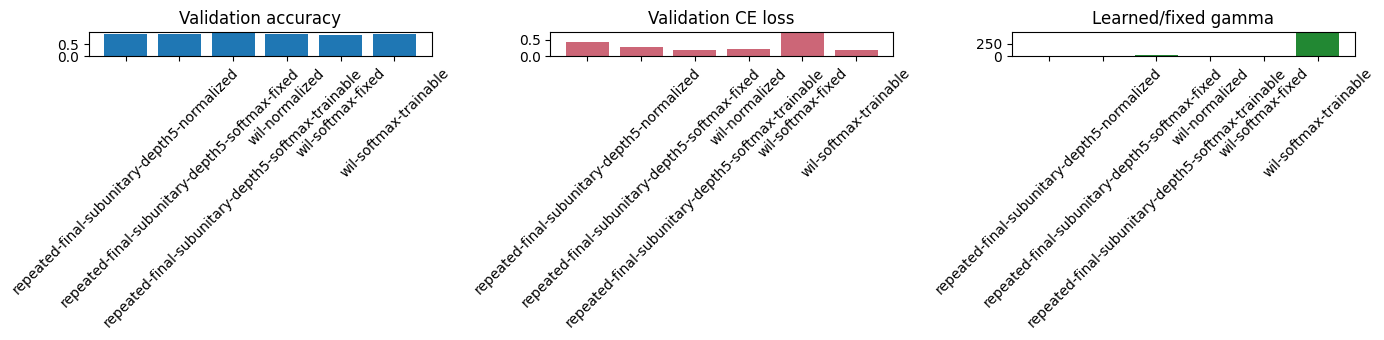

In [4]:
# Keep the depth-5 rows for a compact objective comparison.
rows = [row for row in objective_results if row["layers"] == 5]
labels = [row["name"].replace("repeated-final-subunitary-trainable-phase-depth5-", "rep-").replace("williamson-depth5-", "wil-") for row in rows]
acc = [row["val_accuracy"] for row in rows]
loss = [row["val_loss"] for row in rows]
gamma = [row["final_logit_scale"] for row in rows]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].bar(labels, acc)
axes[0].set_title("Validation accuracy")
axes[0].tick_params(axis="x", rotation=45)
axes[1].bar(labels, loss, color="#cc6677")
axes[1].set_title("Validation CE loss")
axes[1].tick_params(axis="x", rotation=45)
axes[2].bar(labels, gamma, color="#228833")
axes[2].set_title("Learned/fixed gamma")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Ridge Readout

Ridge readout is post-hoc: the optical stack is trained first, raw final intensities are extracted, and a closed-form linear readout is fit. It is useful diagnostically, but it is not the main optical training objective in the core benchmark.


In [5]:
for row in ridge_results:
    print(
        f"{row['name']}: prob_acc={100*row['prob_val_accuracy']:.2f}%, "
        f"ridge_acc={100*row['ridge_val_accuracy']:.2f}%, ridge_mse={row['ridge_val_mse']:.4f}"
    )


repeated-unitary-depth6: prob_acc=94.36%, ridge_acc=94.34%, ridge_mse=0.0187
repeated-unitary-depth7: prob_acc=94.31%, ridge_acc=94.47%, ridge_mse=0.0177
repeated-subunitary-depth6: prob_acc=94.06%, ridge_acc=94.34%, ridge_mse=0.0189
repeated-final-subunitary-depth7: prob_acc=94.37%, ridge_acc=94.51%, ridge_mse=0.0172
williamson-depth6: prob_acc=92.98%, ridge_acc=94.12%, ridge_mse=0.0203
williamson-depth7: prob_acc=93.80%, ridge_acc=93.88%, ridge_mse=0.0188


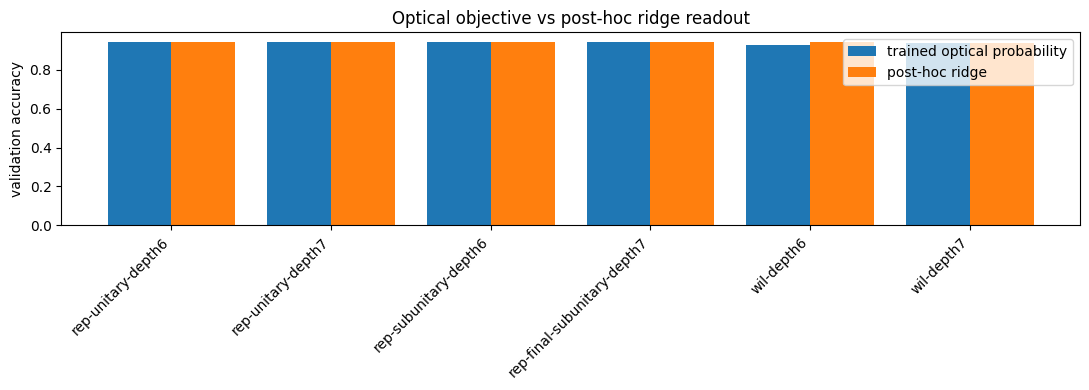

In [6]:
names = [row["name"].replace("repeated-", "rep-").replace("williamson-", "wil-") for row in ridge_results]
prob_acc = [row["prob_val_accuracy"] for row in ridge_results]
ridge_acc = [row["ridge_val_accuracy"] for row in ridge_results]
xpos = np.arange(len(names))

plt.figure(figsize=(11, 4))
plt.bar(xpos - 0.2, prob_acc, width=0.4, label="trained optical probability")
plt.bar(xpos + 0.2, ridge_acc, width=0.4, label="post-hoc ridge")
plt.xticks(xpos, names, rotation=45, ha="right")
plt.ylabel("validation accuracy")
plt.title("Optical objective vs post-hoc ridge readout")
plt.legend()
plt.tight_layout()
plt.show()


## Exercise

Explain why a scalar `gamma` can reduce CE loss without changing the detector argmax. Then inspect whether repeated and Williamson learn similar or different gamma values.
